# 2단계 — 전처리 파이프라인

원시 이메일 텍스트를 정제하여 모델에 입력할 수 있는 형태로 변환합니다.

처리 순서:
1. HTML 태그 제거
2. URL → `[URL]` 토큰
3. 이메일 주소 → `[EMAIL]` 토큰
4. 전화번호 → `[PHONE]` 토큰
5. 특수문자 정리
6. 소문자 변환
7. 공백 정규화

In [1]:
import sys
sys.path.insert(0, '..')

from src.data.preprocessor import Preprocessor

pre = Preprocessor(use_konlpy=False)
print('Preprocessor 준비 완료')

Preprocessor 준비 완료


## HTML 태그 제거

In [2]:
html_text = '<h1>특별 이벤트</h1><p>지금 <b>클릭</b>하세요! <a href="http://spam.com">바로가기</a></p>'
cleaned = pre.clean(html_text)

print('[입력]', html_text)
print('[출력]', cleaned)

[입력] <h1>특별 이벤트</h1><p>지금 <b>클릭</b>하세요! <a href="http://spam.com">바로가기</a></p>
[출력] 특별 이벤트 지금 클릭 하세요 바로가기


## URL / 이메일 / 전화번호 토큰 치환

In [3]:
text = '자세한 내용은 https://spam-site.com/offer?ref=abc 확인 후 spam@bad.com 또는 010-9876-5432 로 연락주세요.'
cleaned = pre.clean(text)

print('[입력]', text)
print('[출력]', cleaned)

[입력] 자세한 내용은 https://spam-site.com/offer?ref=abc 확인 후 spam@bad.com 또는 010-9876-5432 로 연락주세요.
[출력] 자세한 내용은 [url] 확인 후 [email] 또는 [phone] 로 연락주세요


## 전체 전처리: preprocess(subject, body)

In [4]:
subject = '[당첨] 1억원 무료 지급 이벤트!!!'
body = '''
<p>안녕하세요 고객님,</p>
<p>축하합니다! 귀하께서 <b>특별 이벤트</b>에 당첨되셨습니다.</p>
<p>지금 바로 https://free-money.co.kr/claim?token=xyz123 에서 수령하세요.</p>
<p>문의: winner@free-money.co.kr | 010-0000-1234</p>
'''

result = pre.preprocess(subject, body)
print('[제목]', subject)
print('[전처리 결과]')
print(result)

[제목] [당첨] 1억원 무료 지급 이벤트!!!
[전처리 결과]
[당첨] 1억원 무료 지급 이벤트 안녕하세요 고객님 축하합니다 귀하께서 특별 이벤트 에 당첨되셨습니다 지금 바로 [url] 에서 수령하세요 문의 [email] [phone]


## 데이터셋 전체에 전처리 적용

In [ ]:
import pandas as pd
from src.data.loader import load_datasets

data = load_datasets(
    csv_paths=[
        '../data/translated_en_to_ko.csv',
    ],
    preprocessor=pre,
    train_ratio=0.8,
    val_ratio=0.1,
    random_state=42,
)

[데이터] 3개 CSV 병합 → 총 1754개
  스팸: 894개 | 정상: 860개
[전처리] 텍스트 정제 중...
[분리] train=1403 | val=175 | test=176


In [6]:
print('train 샘플 수:', len(data.X_train))
print('val   샘플 수:', len(data.X_val))
print('test  샘플 수:', len(data.X_test))

print('\n--- train 샘플 ---')
for i in range(3):
    label = '스팸' if data.y_train[i] == 1 else '정상'
    print(f'[{label}] {data.X_train[i][:100]}...')

train 샘플 수: 1403
val   샘플 수: 175
test  샘플 수: 176

--- train 샘플 ---
[스팸] 어도비 xp 프로 오피스 2003 어도비 xp 프로 오피스 2003 1 472개 소프트웨어 a z 즉시 다운로드 필요한 소프트웨어를 저렴하게 이용하세요...
[정상] 트랜스웨스턴 트랜스웨스턴 존 밀러가 에릭 가드를 위해 일한다고 생각합니다 그는 트랜스웨스턴 압축기 스테이션 중 하나에 lm 2500을 개발하는 것에 대해 제 팀원들과 이야기했습니다...
[스팸] 제목 없음 제목 없음 시알리스 소프트탭 행동 전 10분에 혀 아래 반 알 녹이기 24시간 효과 자세한 정보는 여기에서...


## 전처리 전/후 길이 비교

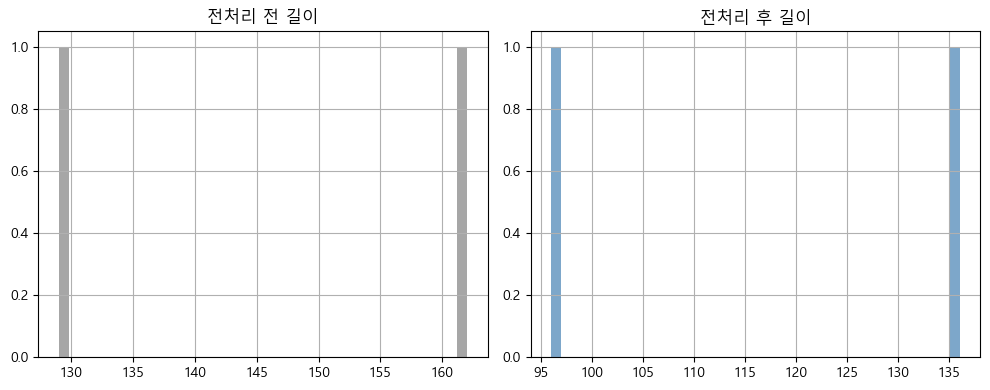

평균 길이: 146 → 116 문자 (20.3% 감소)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("../data/translated_en_to_ko.csv", encoding="utf-8-sig")
df["subject"] = df["subject"].fillna("")
df["body"]    = df["body"].fillna("")
df["raw_len"] = (df["subject"].astype(str) + " " + df["body"].astype(str)).str.len()

cleaned_lens = [
    len(pre.preprocess(str(row["subject"]), str(row["body"])))
    for _, row in df.iterrows()
]
df["clean_len"] = cleaned_lens

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["raw_len"].hist(bins=40, ax=axes[0], color="gray", alpha=0.7)
axes[0].set_title("전처리 전 길이")
df["clean_len"].hist(bins=40, ax=axes[1], color="steelblue", alpha=0.7)
axes[1].set_title("전처리 후 길이")
plt.tight_layout()
plt.show()

reduction = (1 - df["clean_len"].mean() / df["raw_len"].mean()) * 100
print(f'평균 길이: {df["raw_len"].mean():.0f} → {df["clean_len"].mean():.0f} 문자 ({reduction:.1f}% 감소)')

## 전처리와 오버피팅 방지

전처리 자체가 오버피팅 방지에 기여합니다:

| 전처리 단계 | 오버피팅 방지 효과 |
|------------|------------------|
| URL → `[URL]` 토큰 | 특정 URL 문자열 암기 방지 |
| 이메일 → `[EMAIL]` | 특정 도메인 암기 방지 |
| 전화번호 → `[PHONE]` | 특정 번호 패턴 암기 방지 |
| 소문자 변환 | 대소문자 차이로 인한 불필요한 분기 제거 |
| 특수문자 제거 | 노이즈 피처 제거 |

> 토큰 치환 없이 학습하면 모델이 특정 URL/전화번호를 스팸 지표로 암기해 새로운 스팸에 일반화되지 않습니다.